In [1]:
import sys
import os

running_path = "/Odyssey/private/o23gauvr/code/"
os.chdir(running_path)
sys.path.insert(0,running_path)
sys.path.insert(0, "/Odyssey/private/o23gauvr/code/FASCINATION")
#from FASCINATION.src.autoencoder_datamodule_good_split import AEDatamodule


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from FASCINATION.src.bootstrap_codec_inference import load_truth_and_ae_unorm_cpu



In [3]:

# def make_spatial_observation_mask(sample, n_obs, seed=42):
#     """Build a spatial observation mask for one [B, C, H, W] sample."""
#     mask = torch.zeros_like(sample[:, 0, :, :])
#     generator = torch.Generator(device=mask.device)
#     generator.manual_seed(seed)
#     numel = mask.numel()
#     n_obs = min(int(n_obs), numel)
#     idx = torch.randperm(numel, generator=generator, device=mask.device)[:n_obs]
#     mask.view(-1)[idx] = 1
#     return mask.unsqueeze(1).repeat(1, sample.shape[1], 1, 1)

def make_spatial_observation_mask(sample, n_obs, seed=42):
    """Build a spatial observation mask for one [B, C, H, W] sample."""
    mask = np.zeros(sample[:, 0, :, :].shape, dtype=sample.dtype)
    rng = np.random.default_rng(seed)
    numel = mask.size
    n_obs = min(int(n_obs), numel)
    idx = rng.permutation(numel)[:n_obs]
    mask.reshape(-1)[idx] = 1
    return np.repeat(mask[:, np.newaxis, :, :], sample.shape[1], axis=1)

In [14]:
def variance_score(x_train):
    """
    x_train : (T,C,H,W)

    Returns
    -------
    score : (H,W)
    """
    x = x_train.float()

    # variance over time
    var = x.var(dim=0, unbiased=False)      # (C,H,W)

    # average over depth
    score = var.mean(dim=0)                 # (H,W)

    return score.cpu()

def variance_score_np(truth_np):
    """
    x_train : (T,C,H,W)

    Returns
    -------
    score : (H,W)
    """


    # variance over time
    var = truth_np.var(axis=0)              # (C,H,W)

    # average over depth
    score = var.mean(axis=0)                 # (H,W)

    return score


def gradient_score(x_train):
    """
    Mean spatial gradient magnitude.
    """

    x = x_train.float()

    gx = x[...,1:] - x[...,:-1]
    gy = x[:,:,:,1:] - x[:,:,:,:-1]

    gx = torch.nn.functional.pad(gx,(0,1))
    gy = torch.nn.functional.pad(gy,(0,0,0,1))

    grad = torch.sqrt(gx**2 + gy**2)

    score = grad.mean(dim=(0,1))

    return score.cpu()


def gradient_score_np(np_truth):
    """
    Mean spatial gradient magnitude.
    """

    gx = np_truth[...,1:] - np_truth[...,:-1]
    gy = np_truth[:,:,:,1:] - np_truth[:,:,:,:-1]

    gx = np.pad(gx, ((0,0),(0,0),(0,0),(0,1)), mode='constant')
    gy = np.pad(gy, ((0,0),(0,0),(0,0),(0,1)), mode='constant')

    grad = np.sqrt(gx**2 + gy**2)

    score = grad.mean(axis=(0,1))

    return score

def gradient_variance_score_np(np_truth):
    """
    Spatial gradient variance averaged over depth.
    """

    gx = np_truth[...,1:] - np_truth[...,:-1]
    gy = np_truth[:,:,:,1:] - np_truth[:,:,:,:-1]

    gx = np.pad(gx, ((0,0),(0,0),(0,0),(0,1)), mode='constant')
    gy = np.pad(gy, ((0,0),(0,0),(0,0),(0,1)), mode='constant')

    grad = np.sqrt(gx**2 + gy**2)

    score = grad.var(axis=0).mean(axis=0)

    return score


def entropy_score(x_train, bins=32):
    """
    Histogram entropy averaged over depth.
    """

    T,C,H,W = x_train.shape

    score = torch.zeros(H,W)

    x = x_train.cpu()

    for h in range(H):
        for w in range(W):

            ent = 0

            for c in range(C):

                hist = torch.histc(
                    x[:,c,h,w],
                    bins=bins
                )

                p = hist / hist.sum()

                p = p[p>0]

                ent += -(p*torch.log(p)).sum()

            score[h,w]=ent/C

    return score


def entropy_score_np(np_truth, bins=32):
    """
    Histogram entropy averaged over depth.
    """

    T,C,H,W = np_truth.shape

    score = np.zeros((H,W))

    for h in range(H):
        for w in range(W):

            ent = 0

            for c in range(C):

                hist, _ = np.histogram(
                    np_truth[:,c,h,w],
                    bins=bins,
                    density=True
                )

                p = hist / hist.sum()

                p = p[p>0]

                ent += -(p*np.log(p)).sum()

            score[h,w]=ent/C

    return score




In [24]:

def select_points_with_suppression(score, n_points=500, radius=5):
    """
    Select top points with spatial suppression.

    Parameters
    ----------
    score : torch.Tensor
        (H,W) score map. Larger = more important.

    n_points : int
        Number of points to select.

    radius : int
        Suppression radius in grid cells.

    Returns
    -------
    points : list of (h,w)
    """

    score = score.clone()

    H, W = score.shape

    selected = []

    yy, xx = torch.meshgrid(
        torch.arange(H, device=score.device),
        torch.arange(W, device=score.device),
        indexing="ij"
    )

    while len(selected) < n_points:

        # best remaining point
        idx = torch.argmax(score)

        h = idx // W
        w = idx % W

        h = int(h)
        w = int(w)

        selected.append((h,w))

        # suppress neighbourhood
        dist2 = (yy-h)**2 + (xx-w)**2

        mask = dist2 <= radius**2

        score[mask] = -float("inf")

        # stop if nothing remains
        if torch.isinf(score).all():
            break

    return selected



def select_points_with_suppression_np(score, n_points=500, radius=5):
    """
    Select top points with spatial suppression.

    Parameters
    ----------
    score : np.ndarray
        (H,W) score map. Larger = more important.

    n_points : int
        Number of points to select.

    radius : int
        Suppression radius in grid cells.

    Returns
    -------
    points : list of (h,w)
    """

    score = score.copy()

    H, W = score.shape

    selected = []

    yy, xx = np.meshgrid(
        np.arange(H),
        np.arange(W),
        indexing="ij"
    )

    while len(selected) < n_points:

        # best remaining point
        idx = np.argmax(score)

        h = idx // W
        w = idx % W

        h = int(h)
        w = int(w)

        selected.append((h,w))

        # suppress neighbourhood
        dist2 = (yy-h)**2 + (xx-w)**2

        mask = dist2 <= radius**2

        score[mask] = -np.inf

        # stop if nothing remains
        if np.isinf(score).all():
            break

    return selected

In [5]:
ckpt_file = "/Odyssey/private/o23gauvr/code/MLIC/experiments/test_mean_std_along_depth/fixed_weight_loss_64_96_1.0_CR_10000.0_enatl_natl__mean_std_along_depth/20260726_101454/checkpoints/best_checkpoint_rmse.pth.tar"
dm_path = "/Odyssey/private/o23gauvr/code/FASCINATION/pickle/enatl_natl_dm_157_196_256_norm_per_split_filtered_z_uniform_alternate_days_7_60_10.pkl"

In [6]:
truth_np, ae_np = load_truth_and_ae_unorm_cpu(
    checkpoint_file="/Odyssey/private/o23gauvr/code/MLIC/experiments/test_mean_std_along_depth/fixed_weight_loss_64_96_1.0_CR_10000.0_enatl_natl__mean_std_along_depth/20260726_101454/checkpoints/best_checkpoint_rmse.pth.tar",
    datamodule_pickle_path="/Odyssey/private/o23gauvr/code/FASCINATION/pickle/enatl_natl_dm_157_196_256_norm_per_split_filtered_z_uniform_alternate_days_7_60_10.pkl",
    batch_size=8,
    crop_idx=20,
    device=None,
    verbose=True,
)

/Odyssey/private/o23gauvr/miniforge3/envs/fsc/lib/python3.11/site-packages/torch/functional.py:513: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/pytorch_1720538435607/work/aten/src/ATen/native/TensorShape.cpp:3609.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
Codec inference: 100%|██████████| 30/30 [00:05<00:00,  5.48it/s]


In [7]:
t_idx = 0
obs_sample = truth_np[t_idx:t_idx+1]

In [ ]:
#error_map = np.abs(ae_np[t_idx:t_idx+1] - obs_sample).mean(axis=(0,1))
error_map = np.abs(ae_np - truth_np).mean(axis=(0,1))
var_map = variance_score_np(truth_np)
grad_map = gradient_score_np(truth_np)
ent_map = entropy_score_np(truth_np)

In [15]:
grad_var_map = gradient_variance_score_np(truth_np)

In [30]:
n_obs_per_day = 1000

In [31]:
mask = make_spatial_observation_mask(obs_sample, n_obs=n_obs_per_day, seed=42)

In [32]:
obs_points = mask[0, 0].astype(bool)
yy, xx = np.where(obs_points)

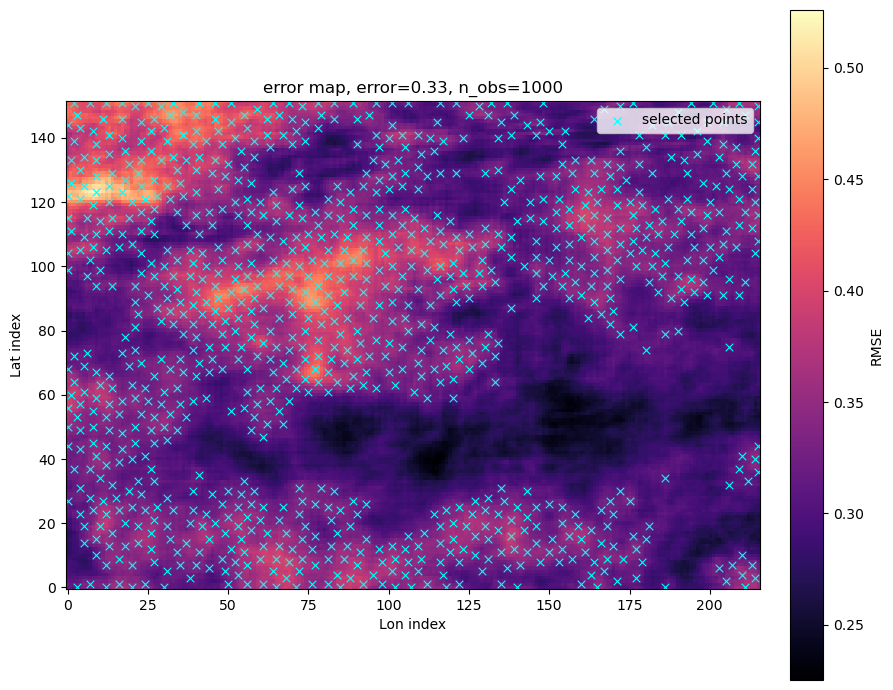

In [39]:

fig, ax = plt.subplots(1, 1, figsize=(9, 7))
im = ax.imshow(error_map, origin="lower", cmap="magma")
#ax.scatter(xx, yy, marker="x", s=30, c="cyan", linewidths=0.8, label="observations")

error_points = select_points_with_suppression_np(error_map, n_points=n_obs_per_day, radius=4)
ax.scatter([p[1] for p in error_points], [p[0] for p in error_points], marker="x", s=30, c="cyan", linewidths=0.8, label="selected points")

ax.set_title(f"error map, error={error_map.mean():.2f}, n_obs={n_obs_per_day}")
ax.set_xlabel("Lon index")
ax.set_ylabel("Lat index")
ax.legend(loc="upper right")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="RMSE")
fig.tight_layout()

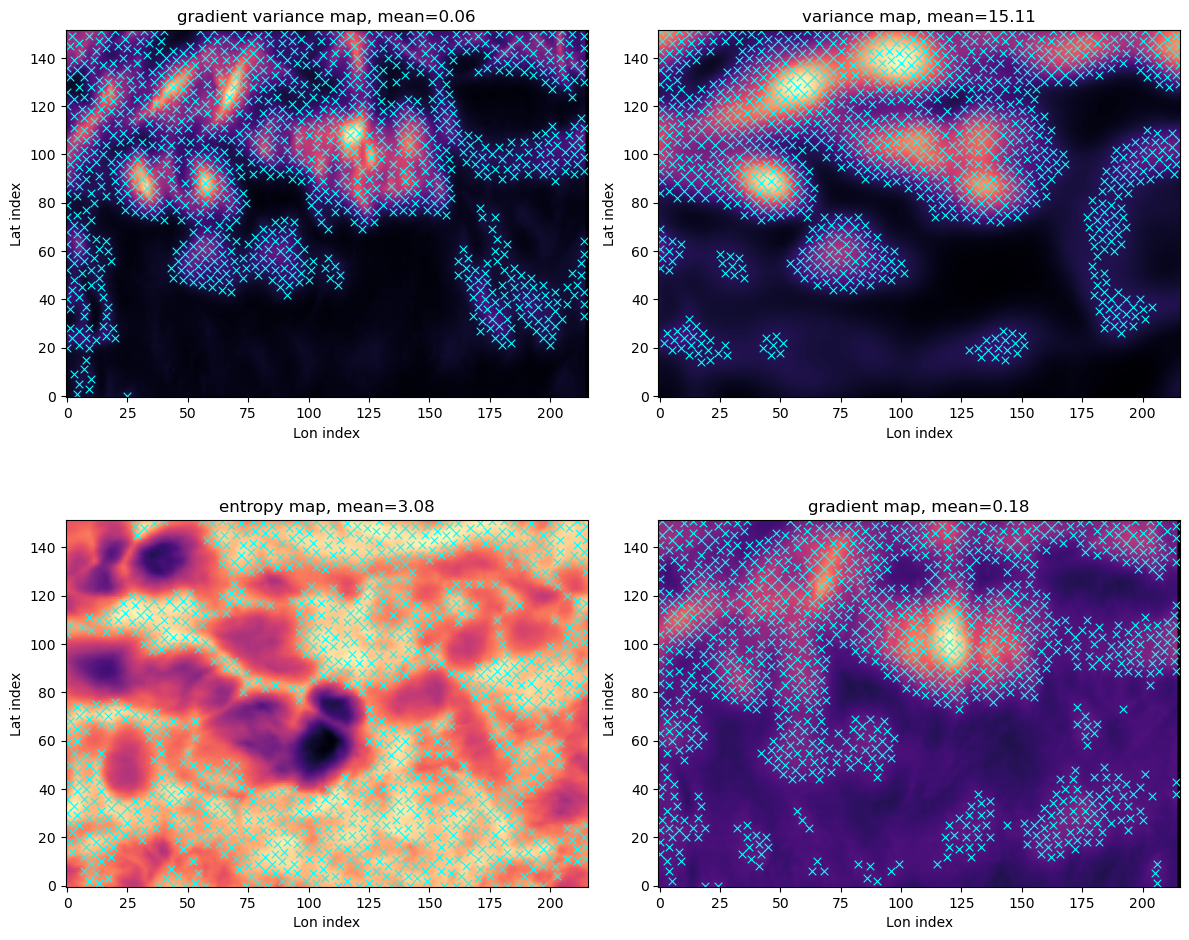

In [38]:
fig,axs = plt.subplots(2, 2, figsize=(12, 10))

axs[0,0].imshow(grad_var_map, origin="lower", cmap="magma")
error_points = select_points_with_suppression_np(grad_var_map, n_points=n_obs_per_day, radius=4)
axs[0,0].scatter([p[1] for p in error_points], [p[0] for p in error_points], marker="x", s=30, c="cyan", linewidths=0.8, label="selected points")
axs[0,0].set_title(f"gradient variance map, mean={grad_var_map.mean():.2f}")
axs[0,0].set_xlabel("Lon index")
axs[0,0].set_ylabel("Lat index")

axs[0,1].imshow(var_map, origin="lower", cmap="magma")
error_points = select_points_with_suppression_np(var_map, n_points=n_obs_per_day, radius=4)
axs[0,1].scatter([p[1] for p in error_points], [p[0] for p in error_points], marker="x", s=30, c="cyan", linewidths=0.8, label="selected points")
axs[0,1].set_title(f"variance map, mean={var_map.mean():.2f}")
axs[0,1].set_xlabel("Lon index")
axs[0,1].set_ylabel("Lat index")    

axs[1,1].imshow(grad_map, origin="lower", cmap="magma")
error_points = select_points_with_suppression_np(grad_map, n_points=n_obs_per_day, radius=4)
axs[1,1].scatter([p[1] for p in error_points], [p[0] for p in error_points], marker="x", s=30, c="cyan", linewidths=0.8, label="selected points")
axs[1,1].set_title(f"gradient map, mean={grad_map.mean():.2f}")
axs[1,1].set_xlabel("Lon index")
axs[1,1].set_ylabel("Lat index")

axs[1,0].imshow(ent_map, origin="lower", cmap="magma")
error_points = select_points_with_suppression_np(ent_map, n_points=n_obs_per_day, radius=4)
axs[1,0].scatter([p[1] for p in error_points], [p[0] for p in error_points], marker="x", s=30, c="cyan", linewidths=0.8, label="selected points")
axs[1,0].set_title(f"entropy map, mean={ent_map.mean():.2f}")
axs[1,0].set_xlabel("Lon index")
axs[1,0].set_ylabel("Lat index")

fig.tight_layout()



Text(0, 0.5, 'depth  index')

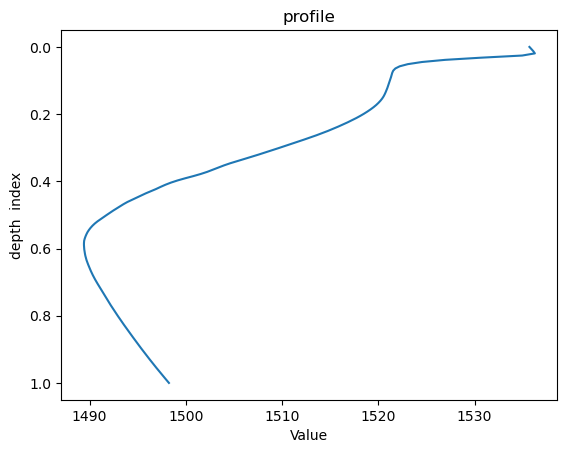

In [43]:
plt.figure()
plt.plot(truth_np[t_idx,:,0,0],np.linspace(0, 1, truth_np.shape[1]), label="truth")
plt.gca().invert_yaxis()
plt.title("profile")
plt.xlabel("Value")
plt.ylabel("depth  index")

In [3]:
ssp = np.array([1535.6003, 1535.8097, 1536.0259, 1536.2169, 1534.9321, 1530.3002,
       1526.7676, 1524.6587, 1523.4587, 1522.797 , 1522.438 , 1522.2289,
       1522.0653, 1521.8939, 1521.695 , 1521.4662, 1521.2124, 1520.9354,
       1520.6432, 1520.3402, 1520.0258, 1519.6908, 1519.3373, 1518.9681,
       1518.5918, 1518.2126, 1517.8252, 1517.4199, 1516.9856, 1516.5238,
       1516.038 , 1515.5317, 1515.0103, 1514.4794, 1513.9374, 1513.3745,
       1512.7865, 1512.177 , 1511.552 , 1510.9113, 1510.2562, 1509.5862,
       1508.9054, 1508.2261, 1507.5493, 1506.8778, 1506.2053, 1505.5146,
       1504.8124, 1504.1082, 1503.4042, 1502.6929, 1501.9729, 1501.2676,
       1500.6134, 1499.9465, 1499.2656, 1498.675 , 1498.1456, 1497.6522,
       1497.1923, 1496.7844, 1496.3367, 1495.8309, 1495.3295, 1494.8291,
       1494.2856, 1493.7491, 1493.2825, 1492.8604, 1492.47  , 1492.1036,
       1491.7633, 1491.4535, 1491.1635, 1490.8812, 1490.5828, 1490.309 ,
       1490.0688, 1489.8673, 1489.721 , 1489.5958, 1489.4945, 1489.4165,
       1489.3639, 1489.3293, 1489.3104, 1489.3074, 1489.3096, 1489.3114,
       1489.3104, 1489.3123, 1489.3247, 1489.3481, 1489.3884, 1489.4338,
       1489.4822, 1489.5322, 1489.5881, 1489.6477, 1489.7114, 1489.7865,
       1489.8674, 1489.955 , 1490.0557, 1490.1631, 1490.2786, 1490.4026,
       1490.5303, 1490.6619, 1490.7968, 1490.9324, 1491.0684, 1491.2064,
       1491.3453, 1491.4854, 1491.6287, 1491.7737, 1491.9268, 1492.0767,
       1492.2273, 1492.3766, 1492.5276, 1492.6799, 1492.8322, 1492.9849,
       1493.1387, 1493.2932, 1493.4484, 1493.6053, 1493.7627, 1493.9205,
       1494.0793, 1494.2389, 1494.3994, 1494.5607, 1494.7222, 1494.8857,
       1495.0499, 1495.2148, 1495.3817, 1495.5493, 1495.7189, 1495.8894,
       1496.061 , 1496.2338, 1496.407 , 1496.582 , 1496.7578, 1496.9348,
       1497.114 , 1497.2941, 1497.4768, 1497.6608, 1497.8463, 1498.0339,
       1498.2225])

Text(0, 0.5, 'depth  index')

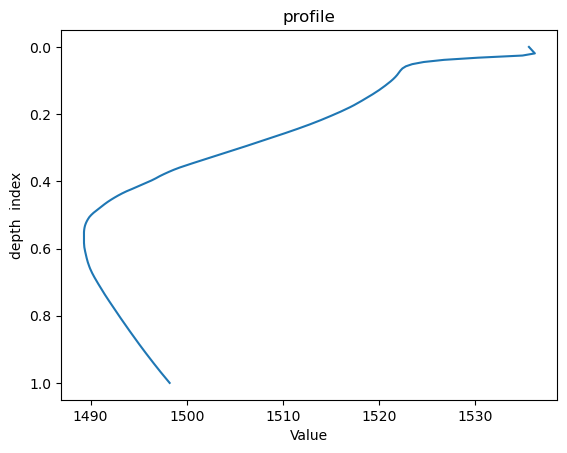

In [5]:
plt.figure()
plt.plot(ssp,np.linspace(0, 1, ssp.shape[0]), label="truth")
plt.gca().invert_yaxis()
plt.title("profile")
plt.xlabel("Value")
plt.ylabel("depth  index")